In [1]:
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

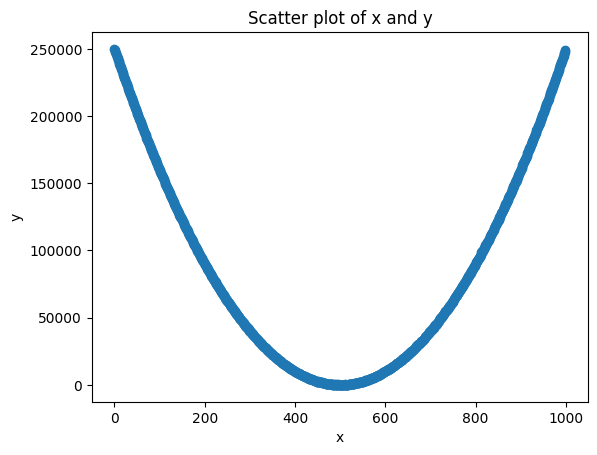

In [2]:
x = list(range(1000))
y = [(i-500)**2 + np.random.normal(0, i/4) for i in x]
df = pd.DataFrame({'x': x, 'y': y})
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y')
plt.show()

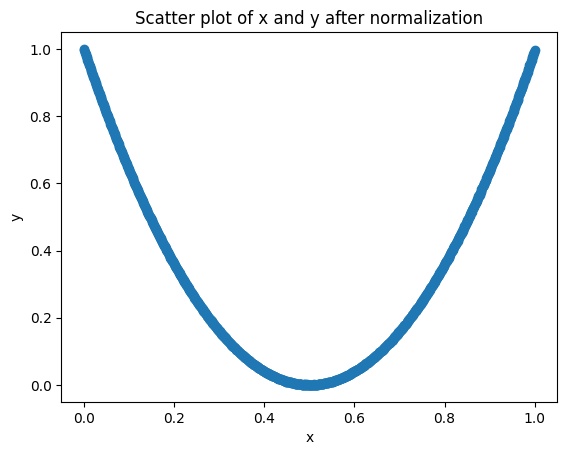

In [3]:
# normalize the data min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after normalization')
plt.show()

In [4]:
x_train = df[['x', 'y']].values
x_train.shape

(1000, 2)

In [5]:
import keras

In [7]:
input_shape = (2,)
#encoder = keras.models.Sequential([keras.layers.Dense(2)])
#decoder = keras.models.Sequential([keras.layers.Dense(input_shape[0])])

stacked_encoder = keras.models.Sequential([
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
        ])

stacked_decoder = keras.models.Sequential([
        keras.layers.Dense(50, activation="relu", input_shape=[1]),
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(input_shape[0], activation="linear"),
        ])



autoencoder = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        stacked_encoder, 
        stacked_decoder
])
autoencoder.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 1)              │         2,751 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 2)              │         2,752 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,503 (21.50 KB)

 Trainable params: 5,503 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
autoencoder.compile(loss="mse", optimizer='adam')
history = autoencoder.fit(x_train, x_train, epochs=150)
codings = stacked_encoder.predict(x_train)

Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1750
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0762 
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0668 
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0548 
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0459 
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0438 
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0429 
Epoch 8/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0413 
Epoch 9/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0397 
Epoch 10/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0375 
Epoch 11/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0352 
Epoch 12/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0313 
Epoch 13/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0247 
Epoch 14/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0173 
Epoch 15/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

In [9]:
T = codings
T.shape

(1000, 1)

In [10]:
T

array([[0.05199198],
       [0.05274323],
       [0.05350402],
       [0.05427362],
       [0.05505351],
       [0.05584181],
       [0.05663989],
       [0.05744941],
       [0.05826634],
       [0.05909266],
       [0.05992831],
       [0.06077867],
       [0.06163387],
       [0.06250356],
       [0.0633815 ],
       [0.06427082],
       [0.06516649],
       [0.06607446],
       [0.06699844],
       [0.06793208],
       [0.06887145],
       [0.06981967],
       [0.07078869],
       [0.071762  ],
       [0.07274383],
       [0.07373553],
       [0.07474223],
       [0.0756961 ],
       [0.07653146],
       [0.07737199],
       [0.0782262 ],
       [0.07907452],
       [0.0799428 ],
       [0.08081504],
       [0.08165921],
       [0.08249412],
       [0.08333702],
       [0.08418329],
       [0.08502895],
       [0.0858945 ],
       [0.08676353],
       [0.08756479],
       [0.08840341],
       [0.08922966],
       [0.09005675],
       [0.09090473],
       [0.09175112],
       [0.092

In [11]:
newdf = stacked_decoder.predict(T)
newdf

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[-1.3807155e-03,  9.9383473e-01],
       [-4.2587891e-04,  9.9062783e-01],
       [ 5.3827837e-04,  9.8736674e-01],
       ...,
       [ 9.9955183e-01,  9.8230940e-01],
       [ 1.0001320e+00,  9.8431778e-01],
       [ 1.0015762e+00,  9.8931623e-01]], shape=(1000, 2), dtype=float32)

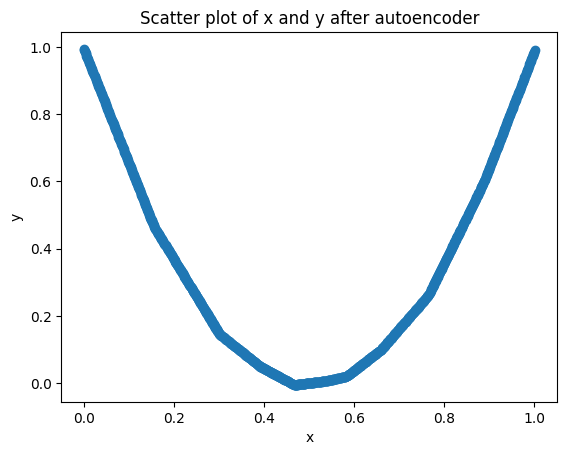

In [12]:
plt.scatter(newdf[:, 0], newdf[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after autoencoder')
plt.show()